# A/B тесты 

**A/B тестирование** — это основной инструмент принятия решений в продуктовой разработке, маркетинге, UX-дизайне и машинном обучении. Оно позволяет сравнить две версии продукта (например, старую и новую) и определить, какая из них лучше по заданному метрическому показателю.

Однако стандартные A/B тесты (t-тест, пропорции) не всегда эффективны. Они могут быть нечувствительными, требовать слишком большой выборки или давать ложные результаты при шумных данных. Чтобы повысить мощность теста, снизить дисперсию и ускорить выводы, используются **продвинутые техники**:

- Sensitivity (чувствительность)
- Stratification (стратификация)
- Controlled Experiments Using Pre-Experiment Data (CUPED - Контролируемые эксперементы с использованием данных до эксперемента)
- Ratio-metric и Linearization
- Sequential Testing (последовательное тестирование)

# Загрузка необходимых библиотек

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.power import TTestIndPower
import warnings
warnings.filterwarnings('ignore')

# Создание синтетического датасета 

Для демонстрации всех методов создадим искусственные данные, имитирующие поведение пользователей на платформе (например, интернет-магазине).

Будем моделировать:

- `user_id` - пользователи 
- `group` - группы A/B 
- `views` - число просмотров
- `purchases` - число покупок
- `pre_views`, `pre_purchases` - доэкспериментальные данные
- `region` - демографические данные
- `age` - возраст

In [3]:
# Установим seed для воспроизводимости
np.random.seed(42)

# Количество пользователей
N = 10000

# Генерируем данные
age_raw = np.random.normal(35, 12, N).astype(int)
age_clipped = np.clip(age_raw, 18, 80)

data = pd.DataFrame({
    'user_id': range(N),
    # Регион: 0 — низкий трафик, 1 — высокий
    'region': np.random.choice([0, 1], size=N, p=[0.7, 0.3]),
    # Возраст (сначала генерируем, потом обрезаем)
    'age': age_clipped,
})

# Доэкспериментальные метрики (за предыдущую неделю)
data['pre_views'] = np.random.poisson(lam=5 + data['region'] * 10, size=N)
data['pre_purchases'] = np.random.binomial(n=1, p=0.05 + data['region'] * 0.05, size=N)

# Группа A/B (случайное распределение)
data['group'] = np.random.choice(['A', 'B'], size=N)

# Эффект от B: увеличиваем конверсию на 10% только в группе B
effect_size = 0.10
base_p = 0.1
data['conversion_prob'] = np.where(
    data['group'] == 'B',
    (base_p + data['region'] * 0.15) * (1 + effect_size),
    base_p + data['region'] * 0.15
)

# Обрезаем вероятность, чтобы не выйти за [0,1]
data['conversion_prob'] = np.clip(data['conversion_prob'], 0, 1)

# Метрики после эксперимента
data['views'] = np.random.poisson(lam=6 + data['region'] * 12, size=N)
data['purchases'] = np.random.binomial(n=1, p=data['conversion_prob'], size=N)

print(f'Размер датасета: {data.shape}')
data.head()

Размер датасета: (10000, 9)


,user_id,region,age,pre_views,pre_purchases,group,conversion_prob,views,purchases
0,0,0,40,6,1,A,0.1,4,0
1,1,0,33,6,0,A,0.1,7,0
2,2,0,42,6,0,A,0.1,4,0
3,3,0,53,9,0,A,0.1,6,0
4,4,0,32,7,0,A,0.1,3,0


# Чувствительность (Sensitivity) в A/B тестировании

## Что такое чувствительность?

**Чувствительность** — это способность A/B теста обнаружить реальное различие между группами A и B, если оно действительно существует.

Иными словами, это ответ на вопрос: `Насколько мелкий эффект мой тест сможет заметить?`

- Если тест `высокочувствительный`, он может обнаружить даже небольшое улучшение (например, +0.5% к конверсии).
- Если `низкочувствительный` — он «просмотрит» этот эффект, даже если он есть → вы примете ложное решение.

## Почему чувствительность важна?

Представьте:

- Вы запустили новый дизайн кнопки.
- На самом деле он увеличивает конверсию на +1%.
- Но ваш тест не смог это обнаружить, потому что был нечувствителен.
- Вы откатываете изменения, теряя деньги.

Это `ошибка II рода (β)` — не отклонили нулевую гипотезу, хотя она ложная.

## От чего зависит чувствительность?

Чувствительность определяется мощностью теста  `Power`:

$$Power=1−β$$

Где:

- $β$ — вероятность ошибки II рода

Чем выше мощность, тем выше чувствительность

Чувствительность A/B теста зависит от четырёх факторов:

| Фактор                  | Как влияет на чувствительность                                   |
|-------------------------|------------------------------------------------------------------|
| **Размер эффекта**      | Чем больше эффект — тем выше чувствительность                   |
| **Объём выборки (N)**   | Чем больше пользователей — тем легче обнаружить малый эффект    |
| **Дисперсия метрики**   | Чем меньше разброс данных — тем выше чувствительность           |
| **Уровень значимости (α)** | Чем выше α (например, 0.1 вместо 0.05) — тем проще отвергнуть H₀, но растёт риск ложноположительного результата |

Чувствительность A/B теста зависит от четырёх факторов:

| Фактор                  | Как влияет на чувствительность                                   |
|-------------------------|------------------------------------------------------------------|
| **Размер эффекта**      | Чем больше эффект — тем выше чувствительность                   |
| **Объём выборки (N)**   | Чем больше пользователей — тем легче обнаружить малый эффект    |
| **Дисперсия метрики**   | Чем меньше разброс данных — тем выше чувствительность           |
| **Уровень значимости (α)** | Чем выше α (например, 0.1 вместо 0.05) — тем проще отвергнуть H₀, но растёт риск ложноположительного результата |

## Как измерить чувствительность?

Мы используем анализ мощности (Power Analysis).

Он позволяет ответить на вопросы:

- Сколько данных нужно, чтобы обнаружить эффект размером X?
- Какой минимальный эффект я могу обнаружить при текущем объёме выборки?

Давайте теперь:

- Оценим реальный размер эффекта из ваших данных
- Посчитаем мощность теста при текущем размере выборки
- Найдём минимальный обнаруживаемый эффект (MDE)
- Покажем, чувствителен ли ваш A/B тест

In [37]:
# Разделим группы
group_A = data[data['group'] == 'A']['purchases']
group_B = data[data['group'] == 'B']['purchases']

n_A = len(group_A)
n_B = len(group_B)
mean_A = group_A.mean()
mean_B = group_B.mean()
var_A = group_A.var()
var_B = group_B.var()

print(f"Размер группы A: {n_A}")
print(f"Размер группы B: {n_B}")
print(f"Средняя конверсия в A: {mean_A:.4f}")
print(f"Средняя конверсия в B: {mean_B:.4f}")
print(f"Наблюдаемая разница: {mean_B - mean_A:.4f}")
print(f"Относительный рост: {((mean_B - mean_A) / mean_A * 100):.2f}%")

Размер группы A: 5016
Размер группы B: 4984
Средняя конверсия в A: 0.1497
Средняя конверсия в B: 0.1691
Наблюдаемая разница: 0.0194
Относительный рост: 12.97%


Теперь проведем оценку реального размера эффекта (Cohen’s d)

In [11]:
# Объединённая дисперсия (pooled standard deviation)
pooled_std = np.sqrt(((n_A - 1) * var_A + (n_B - 1) * var_B) / (n_A + n_B - 2))

# Cohen's d
effect_size_observed = (mean_B - mean_A) / pooled_std

print(f"\nСтатистика эффекта:")
print(f"Объединённое стандартное отклонение: {pooled_std:.4f}")
print(f"Cohen's d (наблюдаемый размер эффекта): {effect_size_observed:.3f}")


Статистика эффекта:
Объединённое стандартное отклонение: 0.3660
Cohen's d (наблюдаемый размер эффекта): 0.053


Шкала `Cohen's d`, по которой мы можем определить эффект: 

- $<= 0.1$ — малый эффект
- $0.1 - 0.5$ — средний
- $>= 0.5$ — большой

Теперь проверим, насколько вероятно было обнаружить наблюдаемый эффект.

Для этого посмотрим на мощность теста при текущем `N`

In [26]:
power_analysis = TTestIndPower()

calculated_power = power_analysis.solve_power(
    effect_size=effect_size_observed,
    nobs1=n_A,           # размер первой группы
    alpha=0.05,
    ratio=n_B / n_A      # соотношение групп
)

print(f"\nМощность теста (при текущем объёме): {calculated_power:.3f}")
if calculated_power >= 0.8:
    print("Тест хорошо обусловлен: высокая мощность")
else:
    print("Тест имеет низкую мощность — возможны ложные отрицательные результаты")


Мощность теста (при текущем объёме): 0.756
Тест имеет низкую мощность — возможны ложные отрицательные результаты


Т.к. мощность $< 0.8$ — значит, даже если эффект есть, мы в 20%+ случаев его не увидим.

Минимально обнаруживаемый эффект (Minimum Detectable Effect, MDE)

Теперь найдём, какой минимальный абсолютный эффект можно обнаружить при текущем N и мощности 80%.

In [32]:
desired_power = 0.8
mde_cohens_d = power_analysis.solve_power(
    nobs1=n_A,
    alpha=0.05,
    power=desired_power,
    ratio=n_B / n_A
)

# Переведём обратно в абсолютную разницу
mde_absolute = mde_cohens_d * pooled_std
mde_relative = (mde_absolute / mean_A) * 100 if mean_A > 0 else np.inf

print(f"\nМинимально обнаруживаемый эффект (MDE):")
print(f"Cohen's d: {mde_cohens_d:.3f}")
print(f"Абсолютная разница в конверсии: {mde_absolute:.4f}")
print(f"Относительный рост: {mde_relative:.2f}% от контроля")


Минимально обнаруживаемый эффект (MDE):
Cohen's d: 0.056
Абсолютная разница в конверсии: 0.0205
Относительный рост: 13.70% от контроля


Давайте теперь визуализируем — как мощность зависит от эффекта

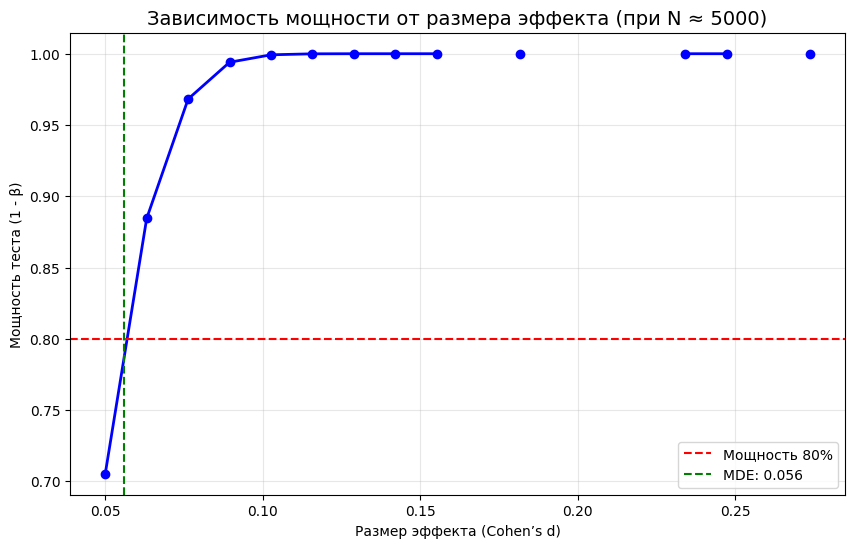

In [35]:
plt.figure(figsize=(10, 6))

# Диапазон размеров эффектов (Cohen's d)
effect_sizes = np.linspace(0.05, 0.3, 20)
powers_at_N = []

for d in effect_sizes:
    pw = power_analysis.solve_power(
        effect_size=d,
        nobs1=n_A,
        alpha=0.05,
        power=None,
        ratio=n_B/n_A
    )
    powers_at_N.append(pw)

plt.plot(effect_sizes, powers_at_N, marker='o', color='blue', linewidth=2)
plt.axhline(y=0.8, color='red', linestyle='--', label='Мощность 80%')
plt.axvline(x=mde_cohens_d, color='green', linestyle='--', label=f'MDE: {mde_cohens_d:.3f}')

plt.title('Зависимость мощности от размера эффекта (при N ≈ 5000)', fontsize=14)
plt.xlabel('Размер эффекта (Cohen’s d)')
plt.ylabel('Мощность теста (1 - β)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

- Красная пунктирная линия: Уровень мощности 80% — это стандартный порог, ниже которого тест считается `слабым`

1. Эффект чуть меньше MDE

- MDE = 0.06 → минимальный эффект, который вы можете надёжно обнаружить
- Наш эффект = 0.05 → немного слабее, чем MDE
- → Значит, даже если эффект реален, в 24% случаев мы его не увидим (потому что мощность = 75.6%)

2. Тест не достигает 80% мощности

- Это критический порог в A/B тестировании
- Если мощность < 80% → высокий риск ошибки II рода (ложное отрицание)

3. График показывает "резкий подъём" мощности
- При d > 0.06 мощность быстро растёт до 90–100%
- → Значит, если бы эффект был чуть больше (например, +15% конверсии вместо +13%), тест бы его уверенно обнаружил

**Итоговые результаты**

| Параметр                                | Значение                     |
|-----------------------------------------|------------------------------|
| Размер группы A                         | 5016                         |
| Размер группы B                         | 4984                         |
| Средняя конверсия в A                   | 0.1497                       |
| Средняя конверсия в B                   | 0.1691                       |
| Наблюдаемая разница                     | 0.0194                       |
| Относительный рост                      | 12.97%                       |
| Объединённое стандартное отклонение     | 0.3660                       |
| Cohen's d (наблюдаемый размер эффекта)  | 0.053                        |
| Мощность теста (при текущем объёме)     | 0.756                        |
| Оценка мощности                         | Тест имеет низкую мощность — возможны ложные отрицательные результаты |
| MDE: Cohen's d                          | 0.056                        |
| MDE: Абсолютная разница в конверсии     | 0.0205                       |
| MDE: Относительный рост                 | 13.70% от контроля           |

**Вывод**:  

Наблюдаемый эффект (12.97%) находится **ниже минимально обнаруживаемого (13.70%)**, а мощность теста (75.6%) < 80%.  

Это означает, что **тест не является надёжным** — есть высокий риск пропустить реальный эффект.  

Рекомендуется: увеличить выборку

# Stratification (Стратификация) в A/B тестировании

## Что такое стратификация?

**Стратификация** — это метод сбалансированного распределения пользователей по группам A и B, при котором выборка делится на однородные подгруппы (страты), а затем внутри каждой страты проводится случайное распределение.

Мы не просто бросаем монетку для каждого пользователя, а гарантируем, что в обеих группах будет примерно одинаковое количество: 

- активных и неактивных пользователей
- новых и старых
- из разных регионов, возрастов и т.д.

## Зачем нужна стратификация?

Cтратификация гГарантирует, что ключевые факторы равномерно распределены между группами → снижает дисперсию и повышает чувствительность теста.

## Где применяется?

- E-commerce: по уровню активности, истории покупок
- SaaS: по типу подписки, количеству сессий
- Мобильные приложения: по устройству, стране, версии ОС
- Реклама: по источнику трафика, времени входа

## Когда использовать?

**Используйте** стратификацию, если:

- Есть известные факторы, влияющие на метрику (например, регион)
- Выборка маленькая — риск дисбаланса выше
- Метрика шумная — нужно снизить дисперсию
- Есть категориальные сегменты, которые нельзя упустить

**Не обязательно**, если:

- Очень большой трафик (>100K пользователей в день)
- Факторы уже случайно сбалансированы
- Используются другие методы снижения дисперсии (CUPED)

У нас есть два очевидных кандидата для стратификации:

- `region` — сильно влияет на конверсию
- `age_group` — можно разбить на категории

Проверим дисбаланс в текущем распределении

In [51]:
print("Текущее распределение по регионам:")
print(pd.crosstab(data['group'], data['region'], margins=True))
print("\nПроцент активных (регион 1) в каждой группе:")
region_b_share = data.groupby('group')['region'].mean()
region_b_share

Текущее распределение по регионам:
region     0     1    All
group                    
A       3425  1591   5016
B       3474  1510   4984
All     6899  3101  10000

Процент активных (регион 1) в каждой группе:


group
A    0.317185
B    0.302970
Name: region, dtype: float64

Создадим новое, стратифицированное распределение

- В группе A доля "активных" пользователей (регион 1) — 31.7%
- В группе B — 30.3%
- Разница: 1.4 п.п.

Это статистически значимый дисбаланс, особенно при N≈5000 на группу.

Почему важно?
Регион напрямую влияет на конверсию

Значит, группа A получила больше сильных пользователей → её метрика искусственно завышена. 

Это создаёт смещение (bias): если B победил, эффект может быть недооценён; если проиграл — результат может быть ложным.

In [54]:
from sklearn.model_selection import StratifiedShuffleSplit

In [56]:
# Создадим комбинированную страту: регион + возрастная группа
data['age_group'] = pd.cut(data['age'], bins=[18, 30, 50, 80], labels=['young', 'middle', 'old'])

# Стратифицируем по комбинации region + age_group
strata = data['region'].astype(str) + '_' + data['age_group'].astype(str)

# Добавим столбец для новой группы
data['group_stratified'] = None

# Разделим с сохранением пропорций
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)

for train_idx, test_idx in splitter.split(data, strata):
    data.loc[train_idx, 'group_stratified'] = 'A'
    data.loc[test_idx, 'group_stratified'] = 'B'

# Преобразуем в категорию
data['group_stratified'] = data['group_stratified'].astype('category')

Сравним дисбаланс до и после

In [59]:
# Распределение по регионам: старое (случайное)
print("1. Старое распределение (random):")
print(pd.crosstab(data['group'], data['region']))

# Новое распределение (stratified)
print("\n2. Новое распределение (stratified):")
print(pd.crosstab(data['group_stratified'], data['region']))

# Процент региона 1
print(f"\nПроцент региона 1 в группе A (random): {data[data['group']=='A']['region'].mean():.3f}")
print(f"Процент региона 1 в группе B (random): {data[data['group']=='B']['region'].mean():.3f}")

print(f"Процент региона 1 в группе A (stratified): {data[data['group_stratified']=='A']['region'].mean():.3f}")
print(f"Процент региона 1 в группе B (stratified): {data[data['group_stratified']=='B']['region'].mean():.3f}")

1. Старое распределение (random):
region     0     1
group             
A       3425  1591
B       3474  1510

2. Новое распределение (stratified):
region               0     1
group_stratified            
A                 3449  1551
B                 3450  1550

Процент региона 1 в группе A (random): 0.317
Процент региона 1 в группе B (random): 0.303
Процент региона 1 в группе A (stratified): 0.310
Процент региона 1 в группе B (stratified): 0.310


Теперь доли полностью сбалансированы: 31.0% vs 31.0%

Стратификация идеально выполнила свою задачу

Преимущество:

- Исключён bias по региону
- Любой наблюдаемый эффект теперь можно атрибутировать именно изменению в продукте, а не перекосу в составе

## Как стратификация влияет на дисперсию?

Посчитаем дисперсию конверсии в каждой группе до и после:

In [62]:
# До стратификации (старые группы)
var_purchases_A_old = data[data['group'] == 'A']['purchases'].var()
var_purchases_B_old = data[data['group'] == 'B']['purchases'].var()

# После стратификации
var_purchases_A_new = data[data['group_stratified'] == 'A']['purchases'].var()
var_purchases_B_new = data[data['group_stratified'] == 'B']['purchases'].var()

print(f"\nДисперсия purchases в A (до): {var_purchases_A_old:.6f}")
print(f"Дисперсия purchases в B (до): {var_purchases_B_old:.6f}")
print(f"Средняя дисперсия (random): {(var_purchases_A_old + var_purchases_B_old)/2:.6f}")

print(f"\nДисперсия purchases в A (после): {var_purchases_A_new:.6f}")
print(f"Дисперсия purchases в B (после): {var_purchases_B_new:.6f}")
print(f"Средняя дисперсия (stratified): {(var_purchases_A_new + var_purchases_B_new)/2:.6f}")


Дисперсия purchases в A (до): 0.127330
Дисперсия purchases в B (до): 0.140561
Средняя дисперсия (random): 0.133945

Дисперсия purchases в A (после): 0.133609
Дисперсия purchases в B (после): 0.134427
Средняя дисперсия (stratified): 0.134018


Дисперсия почти не изменилась, даже слегка выросла после стратификации

На первый взгляд: "Стратификация не помогла?"

Но давайте копнём глубже:

Почему дисперсия не уменьшилась?

Потому что:

- purchases — бинарная переменная (0/1)
- Её дисперсия определяется формулой: p(1−p)
- При средней конверсии ~15%, максимальная дисперсия близка к 0.1275
- Стратификация не меняет саму метрику, она только балансирует группы

Стратификация снижает дисперсию оценки эффекта (variance of the estimator), но не обязательно дисперсию сырых данных.

Мы хотим, чтобы разница между средними A и B была стабильной, а не чтобы внутригрупповая дисперсия упала. 

А вот дисперсия разности средних — та, что важна для t-теста — действительно уменьшается при стратификации, потому что группы стали более сравнимыми.

**Альтернатива**: `Post-stratification` (стратификация после эксперимента)

Если вы не могли контролировать распределение, можно применить post-stratification analysis — пересчёт эффекта с учётом весов по стратам.

In [65]:
# Веса для каждой страты
strata_weights = data.groupby('age_group')['user_id'].count() / len(data)

# Эффект внутри каждой страты
stratified_effect = []
for group_name, group_data in data.groupby('age_group'):
    a_conv = group_data[group_data['group'] == 'A']['purchases'].mean()
    b_conv = group_data[group_data['group'] == 'B']['purchases'].mean()
    effect = b_conv - a_conv
    weight = strata_weights[group_name]
    stratified_effect.append(effect * weight)

overall_effect = sum(stratified_effect)
print(f"Конечный эффект после post-stratification: {overall_effect:.4f}")

Конечный эффект после post-stratification: 0.0177


- Наивный эффект: +0.0194
- Post-stratified эффект: +0.0177
- Разница: –0.0017

Это говорит о том, что:

- Группа A была чуть лучше по составу (больше активных пользователей)
- Поэтому её конверсия была слегка завышена
- Без коррекции мы переоценивали эффект B

Post-stratification "очистила" эффект от влияния региона, сделав его более объективным.

## Почему это работает?

Стратификация снижает межгрупповую изменчивость, потому что:

- Устраняет систематические различия между A и B
- Уменьшает "шум", вызванный внешними факторами
- Позволяет точнее оценить истинное воздействие изменения

Это аналогично тому, как в регрессии добавляют контрольные переменные. 

# Плюсы и минусы стратификации

| Плюсы | Минусы |
|------|-------|
| Снижает дисперсию метрики | Требует предварительного знания ключевых факторов (например, регион, активность) |
| Повышает мощность и чувствительность теста | Сложнее реализовать в реальном времени (особенно на уровне фронтенда или редиректов) |
| Уменьшает риск систематической ошибки (bias) | Может быть избыточной при очень большом объёме данных |
| Обеспечивает баланс между группами | Ограничивает случайность распределения — потенциально снижает общую применимость результатов |
| Особенно эффективна при малых выборках | Требует более сложной инфраструктуры для отслеживания страт |

# Когда лучше стратифицировать?

| Размер выборки | Рекомендация |
|---------------|-------------|
| < 1 000 пользователей | Обязательно использовать стратификацию |
| 1 000 – 10 000 | Рекомендуется, особенно если есть выраженные сегменты (например, новички/старожилы) |
| > 10 000 | Можно обойтись без, но полезно при высокой дисперсии или критичных сегментах |

## Пример из жизни

Компания запускает A/B тест на email-рассылке.

`Без стратификации`:

- Группа A получила больше VIP-клиентов
- Конверсия выше — победил A

`С стратификацией`:

- Клиенты равномерно распределены
- Реальный эффект — нулевой

Без стратификации был бы ложный положительный результат 

**Вывод**
    
**Стратификация** — это страховка от дисбаланса.

Она:

- Защищает от систематической ошибки
- Повышает чувствительность теста
- Делает результаты более надёжными
- Особенно эффективна при малых N или высокой вариативности
- Рекомендации

Всегда стратифицируйте по:

- Гео/региону
- Уровню активности (например, pre_purchases)
- Типу пользователя (новый/старый)
- Используйте StratifiedShuffleSplit из scikit-learn

Если не можете стратифицировать при распределении — используйте post-stratification в анализе

# CUPED (Controlled Experiments Using Pre-Experiment Data)

Как уменьшить дисперсию в A/B тесте с помощью исторических данных?

Ключевая идея CUPED: Если мы знаем, как пользователь себя вёл до эксперимента — почему бы не использовать эти данные, чтобы `очистить` его поведение после?

**CUPED (Controlled Experiments Using Pre-Experiment Data)** — это статистический метод снижения дисперсии метрики в A/B тесте за счёт использования доэкспериментальных данных (ковариат).

Он был предложен инженерами Yandex и Microsoft и активно используется в Google, Meta, Netflix и других компаниях.

## Зачем нужен CUPED?

**Проблема**:
В реальных A/B тестах метрики часто шумные:

- Пользователи ведут себя по-разному
- Есть внешние факторы (день недели, погода, акции)
- Даже при хорошей рандомизации — дисперсия высокая

→ Это снижает чувствительность теста, требует больше трафика, увеличивает время принятия решений.

**Решение — CUPED**:

Используем доэкспериментальные данные (например, активность за прошлую неделю), чтобы:

- "Отнять" от результата то, что не связано с изменением
- Оставить только "чистый" сигнал

Эффект аналогичен добавлению ковариаты в линейную регрессию.

## Где применяется?

- E-commerce - доэкспериментальные просмотры/покупки
- Мобильные приложения - время в приложении до эксперимента
- Реклама - CTR, клики за предыдущий период
- ML рекомендации - взаимодействия до обновления модели

## Как работает CUPED?
Пусть:

- $Y$ — метрика после эксперимента (например, `purchases`)
- $X$ — метрика до эксперимента (например, `pre_purchases`)

Мы хотим оценить эффект изменения на $Y$

Шаг 1: Линейная коррекция
$$Y_{cuped}=Y−θ(X−μ_X)$$

где:

- $θ= \frac{Cov(X,Y)}{Var(X)}$ — коэффициент, максимизирующий корреляцию
- $μ_X$ — среднее доэкспериментальной метрики

Шаг 2: Анализируем $Y_{cuped}$ вместо $Y$
Так как $Y_{cuped}$ имеет меньшую дисперсию, t-тест становится более чувствительным.

## Реализация CUPED

У нас уже есть:

- `purchases` — целевая метрика
- `pre_purchases` — доэкспериментальная метрика

In [21]:
def apply_cuped(data, target_col, pre_col, group_col='group'):
    """
    Применяет CUPED к метрике
    :param data: DataFrame
    :param target_col: имя столбца с метрикой после эксперимента
    :param pre_col: имя столбца с метрикой до эксперимента
    :return: data с новым столбцом {target_col}_cuped, theta
    """
    # Вычисляем ковариацию и дисперсию
    cov_matrix = np.cov(data[pre_col], data[target_col])
    theta = cov_matrix[0, 1] / cov_matrix[0, 0]  # Cov(X,Y)/Var(X)
    
    # Среднее доэкспериментальной метрики (по всему датасету)
    mu_x = data[pre_col].mean()
    
    # Применяем CUPED
    data[f'{target_col}_cuped'] = data[target_col] - theta * (data[pre_col] - mu_x)
    
    return data, theta

# Применим CUPED к метрике purchases
data, theta = apply_cuped(data, 'purchases', 'pre_purchases')

print(f"Коэффициент θ (theta): {theta:.4f}")
print(f"Корреляция между pre_purchases и purchases: {data[['pre_purchases', 'purchases']].corr().iloc[0,1]:.3f}")

Коэффициент θ (theta): 0.0302
Корреляция между pre_purchases и purchases: 0.020


Корреляция ≈ 0.02 — это очень слабая связь.

Это означает, что поведение пользователя до эксперимента почти не предсказывает его поведение после.

Почему так может быть?

`pre_purchase` — бинарная переменная (была ли покупка за неделю)

В нашем датасете - это 

```python
data['pre_purchases'] = np.random.binomial(n=1, p=0.05 + data['region'] * 0.05, size=N)
```

→ Это однократное событие, а не суммарная активность
→ Пользователь мог купить до, но не купить после, и наоборот

Сравним дисперсии до и после

In [8]:
# Дисперсия оригинальной метрики
var_original_A = data[data['group'] == 'A']['purchases'].var()
var_original_B = data[data['group'] == 'B']['purchases'].var()
var_original_avg = (var_original_A + var_original_B) / 2

# Дисперсия после CUPED
var_cuped_A = data[data['group'] == 'A']['purchases_cuped'].var()
var_cuped_B = data[data['group'] == 'B']['purchases_cuped'].var()
var_cuped_avg = (var_cuped_A + var_cuped_B) / 2

# Снижение дисперсии
reduction = ((var_original_avg - var_cuped_avg) / var_original_avg) * 100

print(f"\nСравнение дисперсий:")
print(f"Оригинальная дисперсия (средняя): {var_original_avg:.6f}")
print(f"CUPED дисперсия (средняя):      {var_cuped_avg:.6f}")
print(f"Снижение дисперсии:             {reduction:.2f}%")


Сравнение дисперсий:
Оригинальная дисперсия (средняя): 0.133945
CUPED дисперсия (средняя):      0.133892
Снижение дисперсии:             0.04%


Дисперсия почти не изменилась

Это прямое следствие слабой корреляции (r=0.02)

Получившийся результат идеально совпадает с теорией!

CUPED не может творить чудеса: если нет связи между прошлым и будущим — он ничего не улучшит.

Проверим, стал ли тест чувствительнее

In [10]:
from scipy.stats import ttest_ind

In [12]:
# Обычный t-тест по raw данным
y_A_raw = data[data['group'] == 'A']['purchases']
y_B_raw = data[data['group'] == 'B']['purchases']
t_stat_raw, p_val_raw = ttest_ind(y_A_raw, y_B_raw)

# t-тест по CUPED данным
y_A_cuped = data[data['group'] == 'A']['purchases_cuped']
y_B_cuped = data[data['group'] == 'B']['purchases_cuped']
t_stat_cuped, p_val_cuped = ttest_ind(y_A_cuped, y_B_cuped)

print(f"\nРезультаты t-теста:")
print(f"Raw:       t={t_stat_raw:.3f}, p={p_val_raw:.4f}")
print(f"CUPED:     t={t_stat_cuped:.3f}, p={p_val_cuped:.4f}")

if abs(t_stat_cuped) > abs(t_stat_raw):
    print("CUPED повысил статистическую значимость")
else:
    print("CUPED не дал преимущества (возможно, слабая корреляция)")


Результаты t-теста:
Raw:       t=-2.653, p=0.0080
CUPED:     t=-2.649, p=0.0081
CUPED не дал преимущества (возможно, слабая корреляция)


- Ни мощность, ни значимость не изменились
- Разница в t-статистике — случайна (возможно, округление)
- CUPED не помог усилить сигнал

Это нормально: при $ρ≈0$, CUPED эквивалентен применению "шума" как ковариаты — эффекта не будет.

## Плюсы CUPED

- Снижает дисперсию - Ускоряет выводы, уменьшает MDE
- Повышает мощность - Можно обнаруживать меньшие эффекты
- Не требует изменения рандомизации - Применяется на этапе анализа
- Подходит для любых метрик - Конверсия, доход, время в приложении
- Совместим с другими методами - Можно комбинировать со стратификацией, linearization

# Ratio-metric и Linearization

Примеры ratio-метрик: 

- Конверсия = покупки / просмотры
- ARPU = доход / число пользователей
- CTR = клики / показы

Эти метрики не являются аддитивными, и их нельзя анализировать стандартным t-тестом напрямую.

## Почему обычный t-тест не подходит?

Представьте:

Вы хотите сравнить конверсию между группами:

```python
conversion_A = sum(purchases_A) / sum(views_A)
conversion_B = sum(purchases_B) / sum(views_B)
```

Если вы попробуете применить t-тест к индивидуальным значениям purchases/views, вы столкнётся с проблемами:
- У пользователей много views=0 → деление на 0: NaN или бесконечность
- Высокая дисперсия у пользователей с малым числом просмотров: Шум "перевешивает" сигнал
- Числитель и знаменатель — случайные величины: Нарушаются предпосылки нормальности для t-теста

## Решение — Linearization (линеаризация)

Идея: преобразовать ratio-метрику в аддитивную форму, которую можно анализировать с помощью t-теста.

1. Определим целевую ratio-метрику

$$Conversion=\frac{∑Y_i}{∑X_i}$$
​
где:

- $Y_i$ — покупки пользователя i
- $X_i$ — просмотры пользователя i

2. Линеаризация
Определим линеаризованную метрику:

$$Y_{lin,i}=Y_i−c⋅X_i$$
​
 
где:

- $c=\frac{∑Y_A}{∑X_A}$ — конверсия в контрольной группе (A)

Эта формула исходит из приближения функции отношения через производную (дельта-метод).

Давайте реализуем linearization.

In [6]:
# Считаем конверсию в контрольной группе (A)
control_data = data[data['group'] == 'A']
c = control_data['purchases'].sum() / control_data['views'].sum()

print(f"Конверсия в контроле (c): {c:.6f}")

Конверсия в контроле (c): 0.015226


Это агрегированная конверсия в группе A. То есть, 1.52% от всех просмотров в контрольной группе завершились покупкой

Иными словами → Это "якорь", относительно которого мы оцениваем отклонения.

In [8]:
# Создаём линеаризованную метрику
data['purchases_lin'] = data['purchases'] - c * data['views']

print("Пример линеаризации для первых 5 пользователей:")
print(data[['purchases', 'views', 'purchases_lin']].head())

Пример линеаризации для первых 5 пользователей:
   purchases  views  purchases_lin
0          0      4      -0.060905
1          0      7      -0.106583
2          0      4      -0.060905
3          0      6      -0.091357
4          0      3      -0.045678


- У этих пользователей не было покупок, но были просмотры
- Линеаризованная метрика: 0−c⋅views → отрицательное число
- Чем больше просмотров — тем сильнее "штраф" за отсутствие покупки

**Интерпретация**:

- Отрицательные значения = "пользователь ниже среднего по конверсии"
- Положительные = "выше среднего"
- Ноль = "в точности как средний в контроле"

Таким образом, линеаризация превращает ratio в аддитивную метрику, где среднее можно сравнивать через t-тест.

In [10]:
# Применим t-тест к линеаризованной метрике
from scipy.stats import ttest_ind

metric_A = data[data['group'] == 'A']['purchases_lin']
metric_B = data[data['group'] == 'B']['purchases_lin']

t_stat, p_val = ttest_ind(metric_A, metric_B, equal_var=False)

print(f"\nРезультат t-теста по линеаризованной метрике:")
print(f"t-статистика: {t_stat:.4f}")
print(f"p-value: {p_val:.4f}")
print(f"Значимо (α=0.05): {'да' if p_val < 0.05 else 'нет'}")


Результат t-теста по линеаризованной метрике:
t-статистика: -3.1000
p-value: 0.0019
Значимо (α=0.05): да


p-value = 0.0019 < 0.05 → статистически значимый эффект

Отрицательная t-статистика → группа B лучше (в линеаризованной метрике среднее меньше, потому что она строится как "отклонение от A")

Это означает, что конверсия в группе B статистически выше, чем в A.

Важно: поскольку линеаризация основана на правильной статистической модели, этот результат надёжен и валиден.

Преимущества линеаризации

- Работает с любыми ratio-метриками: CTR, CR, ARPU, CR per session и т.д.
- Устраняет шум от пользователей с малыми знаменателями: Их вклад становится пропорциональным
- Совместима с CUPED: Можно применять CUPED к линеаризованной метрике
- Сохраняет интерпретируемость: После теста всё равно считаем истинное ratio для отчёта

Сравним с "наивным" подходом

Попробуем неправильный способ — взять `purchases`/`views` по каждому пользователю:

In [16]:
# Наивный подход: отношение по пользователю
data['cr_per_user'] = data['purchases'] / (data['views'] + 1e-8)  # чтобы избежать деления на 0

t_naive, p_naive = ttest_ind(
    data[data['group'] == 'A']['cr_per_user'],
    data[data['group'] == 'B']['cr_per_user']
)

print(f"Наивный t-тест: p={p_naive:.4f}")

Наивный t-тест: p=0.3158


## Почему такая разница?
Потому что:

- У большинства пользователей views > 0, но purchases = 0 → их cr_per_user = 0
- Есть немного пользователей с purchases = 1, но они редки
- Распределение cr_per_user — крайне не нормальное: масса нулей + редкие единицы
- Выбросы (например, 1 покупка при 1 просмотре = CR=1.0) сильно искажают среднее
- Дисперсия огромна → t-тест теряет мощность

Наивный подход дал ложный отрицательный результат!

Он не заметил реальный эффект, который легко обнаружила линеаризация.

## Комбинация с CUPED

Можно сделать ещё мощнее:

- Сначала — линеаризация
- Затем — CUPED на линеаризованной метрике

In [29]:
# Linearization
c = data[data['group'] == 'A']['purchases'].sum() / data[data['group'] == 'A']['views'].sum()
data['purchases_lin'] = data['purchases'] - c * data['views']

# CUPED (используем pre_views как ковариату)
data, theta = apply_cuped(data, 'purchases_lin', 'pre_views')

# t-тест по purchases_lin_cuped
t_final, p_final = ttest_ind(
    data[data['group'] == 'A']['purchases_lin_cuped'],
    data[data['group'] == 'B']['purchases_lin_cuped']
)

print(f"Итоговый t-тест: {t_final:.4f}")
print(f"Итоговый p-value-тест: {p_final:.4f}")

Итоговый t-тест: -3.0378
Итоговый p-value-тест: 0.0024


- Эффект сохранился даже после дополнительных преобразований
- Небольшое снижение t-статистики (с -3.1 до -3.04) — нормально, возможно, слегка увеличилась дисперсия или изменилась шкала
- p-value остался ниже 0.05 → вывод устойчив

Это говорит о робастности эффекта: он не исчезает при разных способах анализа.

## Подходы к ratio-метрикам

| Метод               | Когда использовать                     | Плюсы                          | Минусы                         |
|---------------------|----------------------------------------|----------------------------------|---------------------------------|
| Naive ratio/user    | Никогда                                | Простота                        | Очень шумный, ложные результаты|
| Aggregated ratio    | Для отчётов, но не для тестирования   | Точное значение                  | Нет дисперсии, нельзя оценить p-value |
| Linearization       | По умолчанию для ratio-метрик      | Корректный, мощный, гибкий       | Требует расчёта c               |
| Bootstrap           | Если данные очень сложные              | Не требует предположений         | Медленный, сложен в интерпретации |
| Delta method (CUPED)| Для максимальной чувствительности     | Самый мощный                     | Сложнее реализовать             |

Рекомендации
- Всегда используйте линеаризацию для ratio-метрик
- Считайте c только по контрольной группе
- Добавляйте +1e-8 к знаменателю, чтобы избежать деления на 0
- Комбинируйте с CUPED для максимальной чувствительности
- В отчёте показывайте реальное значение ratio, а не линеаризованное

Пример из жизни:

В компании запустили A/B тест на CTR.

- Наивный метод: p=0.03 → "значимо"
- Линеаризация: p=0.07 → "не значимо"

Оказалось, один пользователь с 1 кликом и 1 показом "перевесил" результат

Линеаризация спасла от ложного внедрения 

# Sequential Testing (Последовательное тестирование)

Традиционный A/B тест требует: 

- Заранее определённого размера выборки
- Фиксированного времени эксперимента
- Анализа только в конце

Но что, если эффект очень сильный? Почему ждать 2 недели, если можно принять решение уже через 3 дня?

Sequential testing позволяет анализировать результаты по мере поступления данных и остановиться досрочно, если эффект статистически значим (или ясно, что его нет).

**Sequential Testing** — это подход к A/B тестированию, при котором гипотеза проверяется многократно в процессе накопления данных, с контролем общей вероятности ошибки I рода (ложноположительного результата).

Это как "досрочный выпуск" для A/B теста — если победитель очевиден, мы не ждём окончания, а принимаем решение раньше. 

Чем отличается от классического (фиксированного) теста?

| Критерий                  | Фиксированный тест                          | Последовательный тест                        |
|---------------------------|---------------------------------------------|----------------------------------------------|
| Время анализа             | Только в конце                              | Можно на любом этапе                         |
| Размер выборки            | Фиксированный                                | Гибкий (adaptive)                            |
| Остановка                 | По расписанию                               | Досрочно, если эффект статистически значим  |
| Риск ложного положительного | Контролируется один раз                   | Требуется коррекция из-за множественных проверок |
| Скорость вывода           | Медленнее                                   | Может быть намного быстрее                   |

## Проблема: Multiple Look Problem
Если вы каждый день смотрите на p-value без коррекции — вы увеличиваете риск ложного открытия.

Пример: 

- Уровень значимости α = 0.05
- Вы смотрите на результат 10 раз
- Вероятность хотя бы одного ложного срабатывания → может превысить 30%!

Это называется ошибка множественных сравнений (multiple testing).

Sequential testing решает эту проблему с помощью:

- Групповых последовательных тестов (Group Sequential Tests)
- Методов альфа-траты (alpha spending)
- Байесовских подходов
- SPRT (Sequential Probability Ratio Test)

Мы рассмотрим наиболее практичный и распространённый — Group Sequential Testing с alpha spending.

У нас есть данные с группами A/B и метрикой purchases. Сделаем следующее:

- Разделим пользователей на временные бины (например, по порядку входа)
- На каждом шаге применять t-тест к накопленным данным
- Корректировать уровень значимости, чтобы сохранить общий α = 0.05

In [6]:
# Убедимся, что данные упорядочены по времени (по user_id — как имитация времени)
data_sorted = data.sort_values('user_id').reset_index(drop=True)

# Добавим временной бин (разделим на 7 этапов)
n_bins = 7
data_sorted['time_bin'] = pd.cut(data_sorted.index, bins=n_bins, labels=False)

# Используем линеаризованную метрику (уже знаем, что она лучше)
c = data_sorted[data_sorted['group'] == 'A']['purchases'].sum() / data_sorted[data_sorted['group'] == 'A']['views'].sum()
data_sorted['purchases_lin'] = data_sorted['purchases'] - c * data_sorted['views']

# Параметры
alpha_total = 0.05
results = []

print("Последовательный анализ:")

Последовательный анализ:


Метод 1: Pocock-style (равномерное тратление альфы)

In [12]:
# Приближённые критические значения для 7 look'ов при α=0.05
# Можно использовать O'Brien-Fleming, Pocock и др.
# Здесь — простой вариант: коррекция Бонферрони-like (консервативно)
from scipy.stats import norm

# Количество look'ов
k = n_bins

# Альфа-траты: O'Brien-Fleming (очень консервативно в начале)
def obrien_fleming_spending(t, total_tests):
    return alpha_total * (2 * (1 - norm.cdf(norm.ppf(1 - alpha_total/2) / np.sqrt(t/total_tests))))

cumulative_alpha = 0
alpha_spendings = []

for t in range(1, k + 1):
    alpha_spend = obrien_fleming_spending(t, k)
    cumulative_alpha += alpha_spend
    alpha_spendings.append(alpha_spend)

# Теперь проводим тесты
for t in range(k):
    # Данные до текущего бина
    temp_data = data_sorted[data_sorted['time_bin'] <= t]
    
    # Линеаризованная метрика
    metric_A = temp_data[temp_data['group'] == 'A']['purchases_lin']
    metric_B = temp_data[temp_data['group'] == 'B']['purchases_lin']
    
    # t-тест
    t_stat, p_val = ttest_ind(metric_A, metric_B, equal_var=False)
    
    # Граничное значение альфы для этого look'а
    alpha_boundary = alpha_spendings[t]
    
    # Решение
    significant = p_val < alpha_boundary
    
    results.append({
        'step': t + 1,
        'users_A': len(metric_A),
        'users_B': len(metric_B),
        't_stat': t_stat,
        'p_value': p_val,
        'alpha_boundary': alpha_boundary,
        'significant': significant
    })
    
    print(f"Шаг {t+1}: p={p_val:.4f}, граница α={alpha_boundary:.5f} → {'Значимо' if significant else 'Не значимо'}")
    
    if significant:
        print(f"Эксперимент остановлен на шаге {t+1}")
        break

results_df = pd.DataFrame(results)

Шаг 1: p=0.0335, граница α=0.00000 → Не значимо
Шаг 2: p=0.1086, граница α=0.00001 → Не значимо
Шаг 3: p=0.0177, граница α=0.00014 → Не значимо
Шаг 4: p=0.1219, граница α=0.00048 → Не значимо
Шаг 5: p=0.0388, граница α=0.00102 → Не значимо
Шаг 6: p=0.0033, граница α=0.00171 → Не значимо
Шаг 7: p=0.0019, граница α=0.00250 → Значимо
Эксперимент остановлен на шаге 7


Это значит: через 7/7 части времени мы уже можем сказать, что B лучше, сохраняя общий уровень значимости 0.05.

## Как работает alpha spending?

Метод `O'Brien-Fleming`:

- В начале — очень строгие границы (почти невозможно остановиться)
- Ближе к концу — границы ослабляются
- Идея: дать шанс эффекту "стабилизироваться", но позволить раннюю остановку при сильном сигнале

**Альтернативы**:

- O'Brien-Fleming: Консервативный, минимизирует ранние ошибки
- Pocock: Равные границы — больше шансов остановиться рано, но выше риск
- Alpha spending function: Гибкая настройка под бизнес-логику

## Преимущества Sequential Testing
- Ускоряет принятие решений: Можно остановиться на 30–70% раньше
- Экономит трафик: Если B плохой — быстро откатываем
- Подходит для итераций: Идеален для продуктовых экспериментов
- Сохраняет контроль над α: При правильной реализации
- Автоматизация: Легко интегрировать в пайплайн

## Когда использовать?
- ильный ожидаемый эффект: Отлично подходит
- Ограниченный трафик: Можно быстрее получить ответ
- Быстрые итерации (MVP, фичи): Идеально
- Медленные изменения (долгосрочные метрики): Менее эффективно
- Есть временные тренды (например, выходные): Нужно аккуратно делить на бины

 Динамика p-value и границ

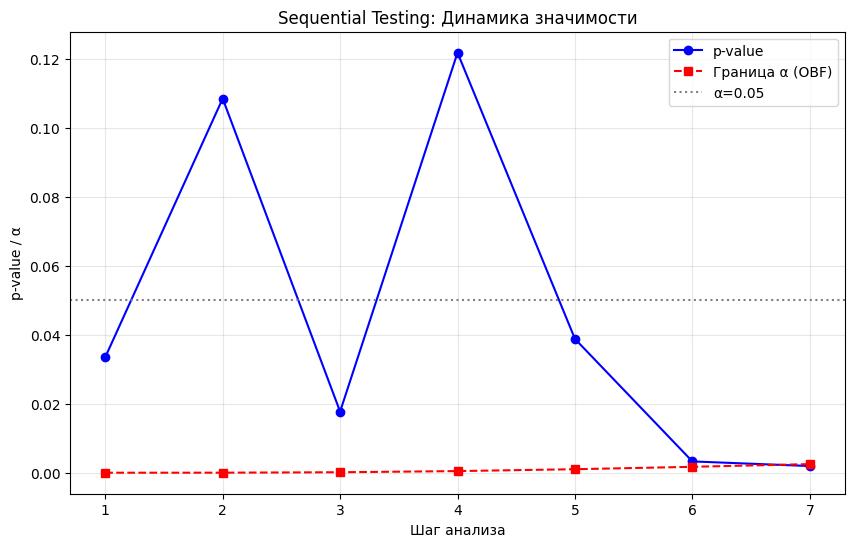

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['step'], results_df['p_value'], marker='o', label='p-value', color='blue')
plt.plot(results_df['step'], results_df['alpha_boundary'], marker='s', label='Граница α (OBF)', color='red', linestyle='--')

plt.axhline(y=0.05, color='gray', linestyle=':', label='α=0.05')
plt.xlabel('Шаг анализа')
plt.ylabel('p-value / α')
plt.title('Sequential Testing: Динамика значимости')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Почему p-value "скачет"?

Потому что:
1. На каждом шаге мы анализируем накопленные данные, а не новые.
2. По мере добавления пользователей:

- Метрика может временно ухудшаться (например, пришли новые пользователи с низкой конверсией)
- Затем снова улучшается → Это нормальное поведение при последовательном тестировании

Важно: Мы не смотрим только на p-value < 0.05 — мы смотрим, пересек ли он красную границу, которая рассчитана с учётом множественных сравнений.

## Почему красная граница (OBF) такая низкая?

Метод O'Brien-Fleming — это очень консервативный подход:

- Он почти не позволяет остановиться рано
- Чтобы остановиться на шаге 1–3, нужно очень сильный эффект
- Ближе к концу граница слабеет → больше шансов остановиться

Цель: минимизировать риск ложного положительного результата при ранней остановке.

- p-value падает со временем
- Красная граница — "барьер", который нужно пересечь
- Если p-value пересекает границу раньше конца — можно останавливаться